In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# 1. Load Data
df = pd.read_csv('../data/raw/aita_10k_sample.csv')

print(f"Dataset Shape: {df.shape}\n")
print("Columns:", df.columns.tolist())
df.head(3)

Dataset Shape: (10000, 9)

Columns: ['id', 'timestamp', 'title', 'body', 'edited', 'verdict', 'score', 'num_comments', 'is_asshole']


,id,timestamp,title,body,edited,verdict,score,num_comments,is_asshole
0,arfcfl,1550365421,AITA - Getting Hugged At The Bar,\n\nThis all happened less than an hour ago.\...,False,not the asshole,3,14,0
1,cg8mxn,1563769917,AITA if i don't want to pay my friend 5 dollar...,"So, my friend bought herself, our other friend...",False,asshole,11,42,1
2,bajsje,1554663842,AITA For going to 'expensive' restaurants in s...,It's in Seattle if that matters. It seems peop...,1554686830.0,asshole,657,397,1


In [2]:
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
id              0
timestamp       0
title           0
body            7
edited          0
verdict         0
score           0
num_comments    0
is_asshole      0
dtype: int64


Missing body text needs to be filtered out during preprocessing.

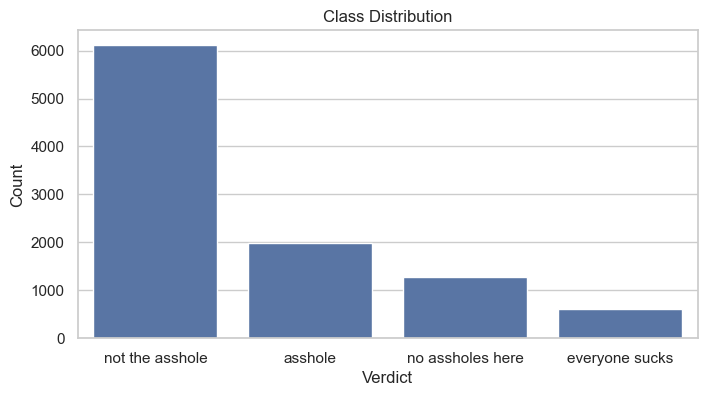


Class Percentages:
verdict
not the asshole     61.19
asshole             19.88
no assholes here    12.88
everyone sucks       6.05
Name: proportion, dtype: float64


In [3]:
# Check unique target values (column name may vary: e.g., 'verdict', 'is_asshole', or 'label')
target_col = 'verdict' if 'verdict' in df.columns else df.columns[-1]

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x=target_col, order=df[target_col].value_counts().index)
plt.title("Class Distribution")
plt.xlabel("Verdict")
plt.ylabel("Count")
plt.show()

print("\nClass Percentages:")
print(df[target_col].value_counts(normalize=True) * 100)

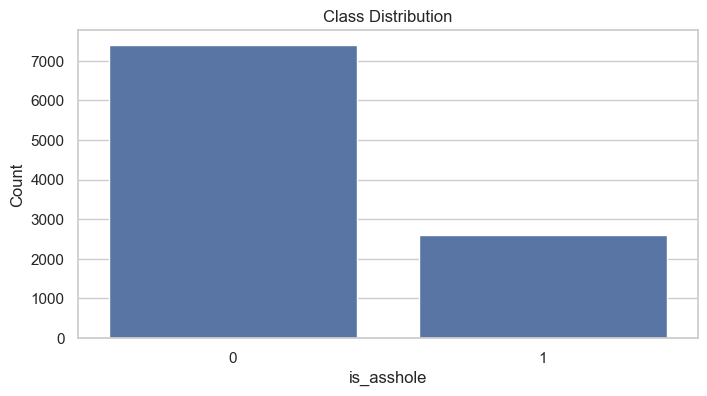


Class Percentages:
is_asshole
0    74.07
1    25.93
Name: proportion, dtype: float64


In [7]:
# Check unique target values (column name may vary: e.g., 'verdict', 'is_asshole', or 'label')
target_col = 'is_asshole' if 'is_asshole' in df.columns else df.columns[-1]

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x=target_col, order=df[target_col].value_counts().index)
plt.title("Class Distribution")
plt.xlabel("is_asshole")
plt.ylabel("Count")
plt.show()

print("\nClass Percentages:")
print(df[target_col].value_counts(normalize=True) * 100)

Slightly imbalanced dataset, should not heavily impact model performance but use metrics F1 recall, precision, confusion matrix as well.

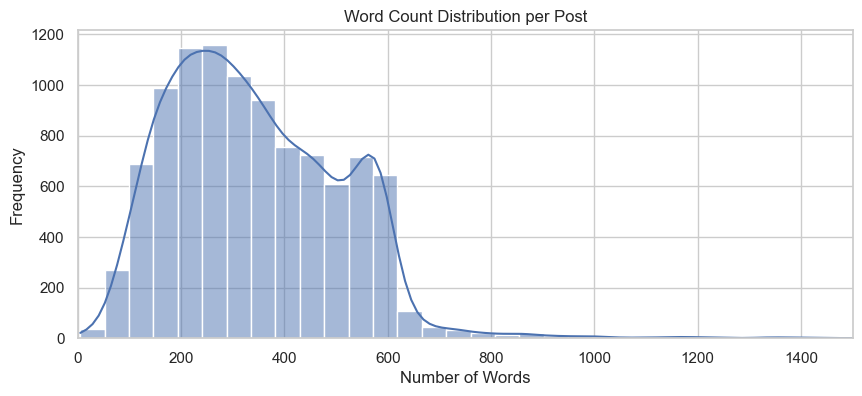

Word Count Summary Statistics:
count    10000.00000
mean       343.44420
std        167.17212
min          5.00000
25%        215.00000
50%        320.00000
75%        460.00000
max       2365.00000
Name: word_count, dtype: float64


In [4]:
# Create combined text field
text_col = 'body' if 'body' in df.columns else 'text'
df['full_text'] = df['title'].fillna('') + " " + df[text_col].fillna('')

# Calculate word count
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))

# Plot word count distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title("Word Count Distribution per Post")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.xlim(0, 1500)  # Cut off extreme long-tail outliers for visualization
plt.show()

print("Word Count Summary Statistics:")
print(df['word_count'].describe())

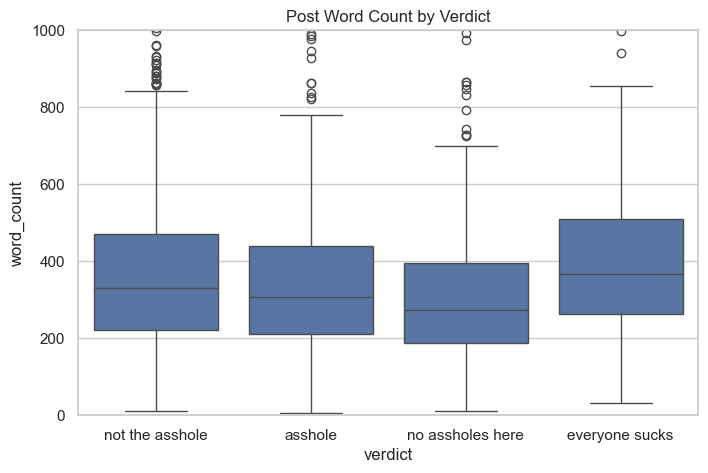

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=target_col, y='word_count')
plt.title("Post Word Count by Verdict")
plt.ylim(0, 1000)
plt.show()

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n_gram_range=(2, 2), top_n=10):
    vec = CountVectorizer(ngram_range=n_gram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_n]

# Example: Top bigrams in full dataset
top_bigrams = get_top_ngrams(df['full_text'].dropna(), n_gram_range=(2, 2), top_n=10)
pd.DataFrame(top_bigrams, columns=['Bigram', 'Frequency'])

,Bigram,Frequency
0,feel like,2342
1,don want,2300
2,don know,1346
3,didn want,1254
4,aita wanting,1200
5,best friend,916
6,years ago,898
7,don think,878
8,aita telling,752
9,year old,737
